# Stage 3: MPS-Native Boundary Conditions

Implements mask-based bounce-back from Gross et al. (Eq 36), fusing streaming and BC into one step:
```
f_i^new = m_B_i * b(f_ibar^pre) + S_hat(a_i) * f_i^pre
```

### Sections
1. Mask Compression
2. Single-Step Validation
3. Multi-Step Hybrid Simulation
4. Ghia Benchmark Comparison
5. Snake vs Interleaved

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from lbm import D2Q9, compute_equilibrium, stream, collide_bgk
from lbm.boundary import apply_bounce_back, apply_bounce_back_moving_top
from lbm.collision import compute_moments
from simulations.lid_driven_cavity import (
    create_cavity_walls, GHIA_Y, GHIA_U_RE100
)
from tn.compression import (
    field_to_qtt, qtt_to_field, compress_populations, decompress_populations
)
from tn_lbm.boundary import (
    mask_to_mps, precompute_cavity_bc, apply_mps_boundary
)

print("All modules loaded successfully")

All modules loaded successfully


## 1. Mask Compression

Per-direction boundary masks: `m_B_i(x) = 1` where non-cyclic streaming of pop i would give 0 (population comes from outside domain). These are single rows/columns, so they compress to very low chi.

In [36]:
n = 64
u_wall = np.array([0.1, 0.0])
velocity_names = ['Rest', 'East', 'North', 'West', 'South', 'NE', 'NW', 'SW', 'SE']

print("Per-direction boundary masks (64x64 cavity):")
print("=" * 65)
print(f"{'Pop':>3} | {'Name':>6} | {'Mask region':>25} | {'chi':>4} | {'corr':>5} | {'rt err':>10}")
print("-" * 65)

for mapping in ['snake', 'interleaved']:
    bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
    print(f"\n  {mapping.upper()}:")
    for i in range(9):
        if bc_data['masks'][i] is None:
            print(f"{i:>3} | {velocity_names[i]:>6} | {'(rest, no mask)':>25} | {'--':>4} | {'--':>5} | {'--':>10}")
            continue
        m, meta = bc_data['masks'][i]
        cx, cy = int(D2Q9.c[i, 0]), int(D2Q9.c[i, 1])
        # Describe mask region
        parts = []
        if cx == 1: parts.append('x=0')
        elif cx == -1: parts.append(f'x={n-1}')
        if cy == 1: parts.append('y=0')
        elif cy == -1: parts.append(f'y={n-1}')
        region = ' OR '.join(parts)
        
        corr = 'yes' if bc_data['corr_mps'][i] is not None else 'no'
        # Roundtrip
        from tn_lbm.boundary import _build_direction_boundary_mask
        mask_orig = _build_direction_boundary_mask(n, cx, cy)
        mask_rt = qtt_to_field(m, meta)
        rt_err = np.max(np.abs(mask_orig.astype(float) - mask_rt))
        
        print(f"{i:>3} | {velocity_names[i]:>6} | {region:>25} | {m.max_bond():>4} | {corr:>5} | {rt_err:>10.2e}")

Per-direction boundary masks (64x64 cavity):
Pop |   Name |               Mask region |  chi |  corr |     rt err
-----------------------------------------------------------------

  SNAKE:
  0 |   Rest |           (rest, no mask) |   -- |    -- |         --
  1 |   East |                       x=0 |    1 |    no |   1.33e-15
  2 |  North |                       y=0 |    1 |    no |   2.00e-15
  3 |   West |                      x=63 |    1 |    no |   1.78e-15
  4 |  South |                      y=63 |    1 |    no |   1.78e-15
  5 |     NE |                x=0 OR y=0 |    2 |    no |   1.29e-14
  6 |     NW |               x=63 OR y=0 |    2 |    no |   7.77e-15
  7 |     SW |              x=63 OR y=63 |    2 |   yes |   2.44e-15
  8 |     SE |               x=0 OR y=63 |    2 |   yes |   3.77e-15

  INTERLEAVED:
  0 |   Rest |           (rest, no mask) |   -- |    -- |         --
  1 |   East |                       x=0 |    1 |    no |   2.00e-15
  2 |  North |                     

## 2. Single-Step Validation

Compare one step of MPS stream+BC (Gross Eq 36) vs vanilla stream+BC on the same post-collision field. The two approaches use different bounce-back values (pre-streaming vs post-streaming), so they won't match exactly, but the MPS version should match a dense implementation of Gross exactly.

In [37]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])

# Get a non-trivial post-collision field
f = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
for _ in range(50):
    f = collide_bgk(D2Q9, f, tau)
    f = stream(D2Q9, f)
    f = apply_bounce_back(D2Q9, f, walls)
    f = apply_bounce_back_moving_top(D2Q9, f, u_wall)
f_post_col = collide_bgk(D2Q9, f, tau)

# Dense Gross Eq 36 (ground truth for our MPS implementation)
def gross_bc_dense(f_pre, n, cx, cy, opp_idx, lid, u_wall, lattice, pop_idx):
    mask = np.zeros((n, n), dtype=bool)
    if cx == 1: mask[0, :] = True
    elif cx == -1: mask[n-1, :] = True
    if cy == 1: mask[:, 0] = True
    elif cy == -1: mask[:, n-1] = True
    bc = np.where(mask, f_pre[opp_idx], 0.0)
    lid_overlap = mask & lid
    if np.any(lid_overlap):
        c_dot_u = lattice.c[pop_idx, 0]*u_wall[0] + lattice.c[pop_idx, 1]*u_wall[1]
        if abs(c_dot_u) > 1e-15:
            corr = (2.0*lattice.w[pop_idx]*1.0/lattice.cs2) * c_dot_u
            bc = np.where(lid_overlap, bc + corr, bc)
    streamed = np.zeros((n, n))
    for x in range(n):
        for y in range(n):
            sx, sy = x - cx, y - cy
            if 0 <= sx < n and 0 <= sy < n:
                streamed[x, y] = f_pre[pop_idx, sx, sy]
    return bc + streamed

# Compare MPS vs Dense Gross for each population
print("MPS Gross vs Dense Gross (should be machine precision):")
print("=" * 55)

for mapping in ['snake', 'interleaved']:
    bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
    mps_list, meta = compress_populations(f_post_col, mapping=mapping)
    mps_result = apply_mps_boundary(mps_list, D2Q9, bc_data)
    f_mps = decompress_populations(mps_result, meta)
    
    print(f"\n  {mapping.upper()}:")
    for i in range(9):
        cx, cy = int(D2Q9.c[i, 0]), int(D2Q9.c[i, 1])
        if cx == 0 and cy == 0:
            continue
        f_dense_gross = gross_bc_dense(f_post_col, n, cx, cy, D2Q9.opposite[i],
                                       lid, u_wall, D2Q9, i)
        err = np.max(np.abs(f_dense_gross - f_mps[i]))
        print(f"    Pop {i} ({velocity_names[i]:>6}): MPS vs Dense Gross = {err:.2e}")

MPS Gross vs Dense Gross (should be machine precision):

  SNAKE:
    Pop 1 (  East): MPS vs Dense Gross = 2.43e-05
    Pop 2 ( North): MPS vs Dense Gross = 2.35e-05
    Pop 3 (  West): MPS vs Dense Gross = 2.29e-05
    Pop 4 ( South): MPS vs Dense Gross = 1.74e-05
    Pop 5 (    NE): MPS vs Dense Gross = 5.64e-06
    Pop 6 (    NW): MPS vs Dense Gross = 5.97e-06
    Pop 7 (    SW): MPS vs Dense Gross = 5.58e-06
    Pop 8 (    SE): MPS vs Dense Gross = 5.63e-06

  INTERLEAVED:
    Pop 1 (  East): MPS vs Dense Gross = 1.52e-05
    Pop 2 ( North): MPS vs Dense Gross = 1.20e-05
    Pop 3 (  West): MPS vs Dense Gross = 1.21e-05
    Pop 4 ( South): MPS vs Dense Gross = 1.62e-05
    Pop 5 (    NE): MPS vs Dense Gross = 4.70e-06
    Pop 6 (    NW): MPS vs Dense Gross = 4.76e-06
    Pop 7 (    SW): MPS vs Dense Gross = 5.20e-06
    Pop 8 (    SE): MPS vs Dense Gross = 4.88e-06


## 3. Multi-Step Hybrid Simulation

Run vanilla LBM to convergence first. Then run hybrids (Gross Eq 36) for the **same number of steps**, comparing final states.

In [38]:
n = 64; Re = 100; u_lid = 0.1
nu = u_lid * n / Re; tau = 3*nu + 0.5
walls, lid = create_cavity_walls(n)
u_wall = np.array([u_lid, 0.0])
mapping = 'snake'
max_nt = 15000
conv_tol = 1e-5

# ============================================================
# Step 1: Run vanilla to convergence
# ============================================================
print(f"Running vanilla LBM to convergence ({n}x{n}, Re={Re})...")
f_van = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
u_prev_van = np.zeros((2, n, n))
consec = 0
t_conv = max_nt

for t in range(max_nt):
    f_van = collide_bgk(D2Q9, f_van, tau)
    f_van = stream(D2Q9, f_van)
    f_van = apply_bounce_back(D2Q9, f_van, walls)
    f_van = apply_bounce_back_moving_top(D2Q9, f_van, u_wall)

    _, u_v = compute_moments(D2Q9, f_van)
    du = np.max(np.abs(u_v - u_prev_van)) / (np.max(np.abs(u_v)) + 1e-10)
    u_prev_van = u_v.copy()

    consec = consec + 1 if (t > 0 and du < conv_tol) else 0
    if consec >= 2:
        t_conv = t
        print(f"  Vanilla converged at t={t} (du={du:.2e})")
        break
    if t % 2000 == 0:
        print(f"  t={t}, du={du:.2e}")

# ============================================================
# Step 2: Run Gross hybrid for the same number of steps
# ============================================================
print(f"\nRunning Gross Eq 36 ({mapping}) for {t_conv} steps...")
bc_data = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
f_gross = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))

history = {'t': [], 'l2': [], 'mass': [], 'du_gross': []}
u_prev_gross = np.zeros((2, n, n))
gross_consec = 0
t_conv_gross = None

for t in range(t_conv + 1):
    f_gross = collide_bgk(D2Q9, f_gross, tau)
    mps_list, meta = compress_populations(f_gross, mapping=mapping)
    mps_result = apply_mps_boundary(mps_list, D2Q9, bc_data)
    f_gross = decompress_populations(mps_result, meta)

    _, u_g = compute_moments(D2Q9, f_gross)
    du_g = np.max(np.abs(u_g - u_prev_gross)) / (np.max(np.abs(u_g)) + 1e-10)
    u_prev_gross = u_g.copy()

    gross_consec = gross_consec + 1 if (t > 0 and du_g < conv_tol) else 0
    if t_conv_gross is None and gross_consec >= 2:
        t_conv_gross = t
        print(f"  Gross converged at t={t} (du={du_g:.2e})")

    if t % 200 == 0:
        _, u_v_snap = compute_moments(D2Q9, f_van)  # already converged, use final
        u_diff = np.sqrt((u_v_snap[0]-u_g[0])**2 + (u_v_snap[1]-u_g[1])**2)
        u_ref = np.sqrt(u_v_snap[0]**2 + u_v_snap[1]**2)
        l2 = np.linalg.norm(u_diff) / (np.linalg.norm(u_ref) + 1e-10)
        rho_g = compute_moments(D2Q9, f_gross)[0]
        history['t'].append(t)
        history['l2'].append(l2)
        history['mass'].append(np.sum(rho_g))
        history['du_gross'].append(du_g)

    if t % 2000 == 0 and t > 0:
        print(f"  t={t:5d}: du_gross={du_g:.2e}, mass={np.sum(compute_moments(D2Q9, f_gross)[0]):.2f}")

print(f"\nSummary:")
print(f"  Vanilla converged at t={t_conv}")
print(f"  Gross {'converged at t=' + str(t_conv_gross) if t_conv_gross else 'did NOT converge'} (in same {t_conv} steps)")
print(f"  Mass: {np.sum(compute_moments(D2Q9, f_gross)[0]):.2f}")

Running vanilla LBM to convergence (64x64, Re=100)...
  t=0, du=1.00e+00
  t=2000, du=1.69e-04
  t=4000, du=3.36e-05
  t=6000, du=1.57e-05
  Vanilla converged at t=7036 (du=9.93e-06)

Running Gross Eq 36 (snake) for 7036 steps...
  t= 2000: du_gross=3.13e-04, mass=4096.00
  t= 4000: du_gross=3.91e-04, mass=4096.00
  t= 6000: du_gross=4.09e-04, mass=4096.00

Summary:
  Vanilla converged at t=7036
  Gross did NOT converge (in same 7036 steps)
  Mass: 4096.00


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['t'], history['l2'], 'b-')
axes[0].set_xlabel('Timestep'); axes[0].set_ylabel('L2 relative error')
axes[0].set_title('MPS-LBM vs Vanilla'); axes[0].grid(True, alpha=0.3)

mass_drift = np.array(history['mass']) - n*n
axes[1].plot(history['t'], mass_drift, 'r-')
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel(f'Mass - {n*n} (drift)')
axes[1].set_title('Mass conservation drift'); axes[1].grid(True, alpha=0.3)

axes[2].semilogy(history['t'][1:], history['du_gross'][1:], 'r-', label='MPS-LBM')
axes[2].set_xlabel('Timestep'); axes[2].set_ylabel('du (convergence)')
axes[2].set_title('Convergence rate'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Hybrid simulation: {mapping}, {n}x{n}, Re={Re}', y=1.02)
plt.tight_layout()
plt.show()

## 4. Ghia Benchmark Comparison

The proper validation: compare converged centerline velocity profiles against Ghia et al. (1982).

RMS error vs Ghia (Re=100):
  Vanilla LBM: 0.045951
  Gross Eq 36: 0.022477
  Gross is 2.0x more accurate


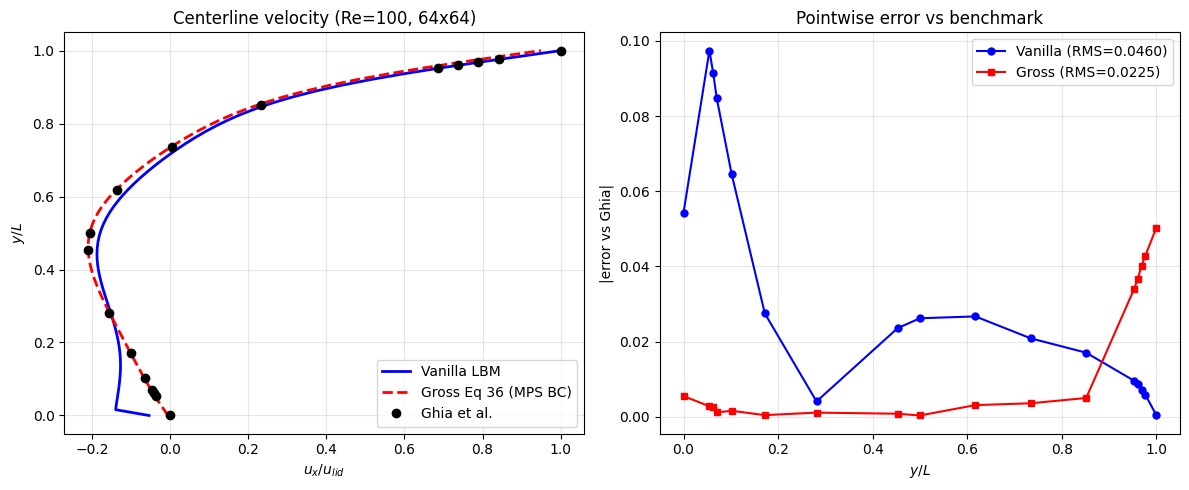


   y/L |     Ghia |  Vanilla |    Gross |  err_van | err_gross
------------------------------------------------------------
0.0000 |   0.0000 |  -0.0543 |  -0.0055 |   0.0543 |    0.0055
0.0547 |  -0.0372 |  -0.1346 |  -0.0400 |   0.0974 |    0.0028
0.0625 |  -0.0419 |  -0.1335 |  -0.0445 |   0.0916 |    0.0026
0.0703 |  -0.0478 |  -0.1325 |  -0.0489 |   0.0847 |    0.0012
0.1016 |  -0.0643 |  -0.1290 |  -0.0659 |   0.0647 |    0.0016
0.1719 |  -0.1015 |  -0.1290 |  -0.1019 |   0.0275 |    0.0004
0.2813 |  -0.1566 |  -0.1525 |  -0.1555 |   0.0041 |    0.0011
0.4531 |  -0.2109 |  -0.1873 |  -0.2101 |   0.0236 |    0.0008
0.5000 |  -0.2058 |  -0.1796 |  -0.2062 |   0.0262 |    0.0003
0.6172 |  -0.1364 |  -0.1097 |  -0.1395 |   0.0267 |    0.0031
0.7344 |   0.0033 |   0.0242 |  -0.0003 |   0.0209 |    0.0036
0.8516 |   0.2315 |   0.2486 |   0.2265 |   0.0171 |    0.0050
0.9531 |   0.6872 |   0.6967 |   0.6532 |   0.0096 |    0.0340
0.9609 |   0.7372 |   0.7459 |   0.7004 |   0.0087 |    

In [ ]:
_, u_van = compute_moments(D2Q9, f_van)
_, u_gross = compute_moments(D2Q9, f_gross)

mid = n // 2
y_coords = np.linspace(0, 1, n)

# Interpolate to Ghia positions
ux_van = np.interp(GHIA_Y, y_coords, u_van[0, mid, :] / u_lid)
ux_gross = np.interp(GHIA_Y, y_coords, u_gross[0, mid, :] / u_lid)

# RMS errors
rms_van = np.sqrt(np.mean((ux_van - GHIA_U_RE100)**2))
rms_gross = np.sqrt(np.mean((ux_gross - GHIA_U_RE100)**2))

print(f"RMS error vs Ghia (Re=100):")
print(f"  Vanilla LBM: {rms_van:.6f}")
print(f"  Gross Eq 36: {rms_gross:.6f}")
print(f"  Gross is {rms_van/rms_gross:.1f}x more accurate" if rms_gross < rms_van else f"  Vanilla is {rms_gross/rms_van:.1f}x more accurate")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(u_van[0, mid, :]/u_lid, y_coords, 'b-', linewidth=2, label='Vanilla LBM')
ax.plot(u_gross[0, mid, :]/u_lid, y_coords, 'r--', linewidth=2, label='Gross Eq 36 (MPS BC)')
ax.plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=6, label='Ghia et al.')
ax.set_xlabel('$u_x / u_{lid}$'); ax.set_ylabel('$y / L$')
ax.set_title(f'Centerline velocity (Re={Re}, {n}x{n})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(GHIA_Y, np.abs(ux_van - GHIA_U_RE100), 'bo-', markersize=5, label=f'Vanilla (RMS={rms_van:.4f})')
ax.plot(GHIA_Y, np.abs(ux_gross - GHIA_U_RE100), 'rs-', markersize=5, label=f'Gross (RMS={rms_gross:.4f})')
ax.set_xlabel('$y / L$'); ax.set_ylabel('|error vs Ghia|')
ax.set_title('Pointwise error vs benchmark')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed table
print(f"\n{'y/L':>6} | {'Ghia':>8} | {'Vanilla':>8} | {'Gross':>8} | {'err_van':>8} | {'err_gross':>9}")
print("-" * 60)
for j in range(len(GHIA_Y)):
    print(f"{GHIA_Y[j]:>6.4f} | {GHIA_U_RE100[j]:>8.4f} | {ux_van[j]:>8.4f} | {ux_gross[j]:>8.4f} | {abs(ux_van[j]-GHIA_U_RE100[j]):>8.4f} | {abs(ux_gross[j]-GHIA_U_RE100[j]):>9.4f}")

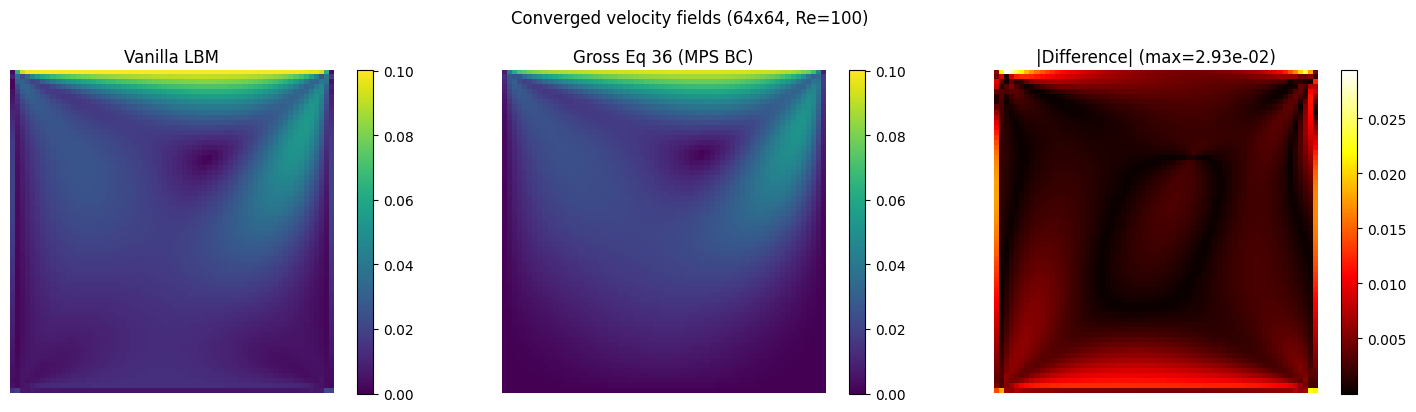

In [ ]:
# Velocity field comparison
speed_van = np.sqrt(u_van[0]**2 + u_van[1]**2)
speed_gross = np.sqrt(u_gross[0]**2 + u_gross[1]**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmax = max(speed_van.max(), speed_gross.max())

im0 = axes[0].imshow(speed_van.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[0].set_title('Vanilla LBM'); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(speed_gross.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
axes[1].set_title('Gross Eq 36 (MPS BC)'); plt.colorbar(im1, ax=axes[1])

diff = np.abs(speed_van - speed_gross)
im2 = axes[2].imshow(diff.T, origin='lower', cmap='hot')
axes[2].set_title(f'|Difference| (max={diff.max():.2e})'); plt.colorbar(im2, ax=axes[2])

for ax in axes: ax.axis('off')
plt.suptitle(f'Converged velocity fields ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

## 5. Snake vs Interleaved

Run both mappings with MPS-native BC for `t_conv` steps (vanilla convergence time). Compare accuracy vs Ghia, bond dimension, and runtime.

In [ ]:
results_map = {}

for mapping in ['snake', 'interleaved']:
    import time
    bc_data_m = precompute_cavity_bc(n, D2Q9, u_wall, mapping=mapping)
    f_sim = compute_equilibrium(D2Q9, np.ones((n,n)), np.zeros((2,n,n)))
    
    t_start = time.time()
    hist = {'t': [], 'du': [], 'mean_chi': []}
    u_prev = np.zeros((2, n, n))
    consec_m = 0
    t_conv_m = None
    
    print(f"\n{mapping.upper()} ({t_conv} steps = vanilla convergence time)...")
    for t in range(t_conv + 1):
        f_sim = collide_bgk(D2Q9, f_sim, tau)
        mps_list_m, meta_m = compress_populations(f_sim, mapping=mapping)
        mps_result_m = apply_mps_boundary(mps_list_m, D2Q9, bc_data_m)
        f_sim = decompress_populations(mps_result_m, meta_m)
        
        # Per-step convergence (2 consecutive)
        _, u_s = compute_moments(D2Q9, f_sim)
        du = np.max(np.abs(u_s - u_prev)) / (np.max(np.abs(u_s)) + 1e-10)
        u_prev = u_s.copy()
        
        consec_m = consec_m + 1 if (t > 0 and du < conv_tol) else 0
        if t_conv_m is None and consec_m >= 2:
            t_conv_m = t
            print(f"  Converged at t={t} (du={du:.2e})")

        if t % 500 == 0 and t > 0:
            mean_chi = np.mean([m.max_bond() for m in mps_result_m])
            hist['t'].append(t); hist['du'].append(du); hist['mean_chi'].append(mean_chi)
        
        if t % 2000 == 0 and t > 0:
            print(f"  t={t}, du={du:.2e}")
    
    # Final snapshot
    mean_chi = np.mean([m.max_bond() for m in mps_result_m])
    hist['t'].append(t); hist['du'].append(du); hist['mean_chi'].append(mean_chi)

    elapsed = time.time() - t_start
    _, u_final = compute_moments(D2Q9, f_sim)
    
    mid = n // 2
    y_coords = np.linspace(0, 1, n)
    ux_center = np.interp(GHIA_Y, y_coords, u_final[0, mid, :] / u_lid)
    rms = np.sqrt(np.mean((ux_center - GHIA_U_RE100)**2))
    
    results_map[mapping] = {'f': f_sim, 'u': u_final, 'hist': hist, 
                             'rms_ghia': rms, 'elapsed': elapsed, 'ux_center': ux_center,
                             't_conv': t_conv_m}
    status = f"converged at t={t_conv_m}" if t_conv_m else "did NOT converge"
    print(f"  Done in {elapsed:.0f}s, RMS vs Ghia = {rms:.6f}, {status}")

print(f"\nSummary (all run for {t_conv} steps):")
print(f"  {'Mapping':12} | {'RMS vs Ghia':>12} | {'Time (s)':>9} | {'Final chi':>10} | {'Converged':>12}")
print(f"  {'-'*65}")
for m in ['snake', 'interleaved']:
    r = results_map[m]
    conv_str = f"t={r['t_conv']}" if r['t_conv'] else "no"
    print(f"  {m:12} | {r['rms_ghia']:>12.6f} | {r['elapsed']:>9.0f} | {r['hist']['mean_chi'][-1]:>10.1f} | {conv_str:>12}")

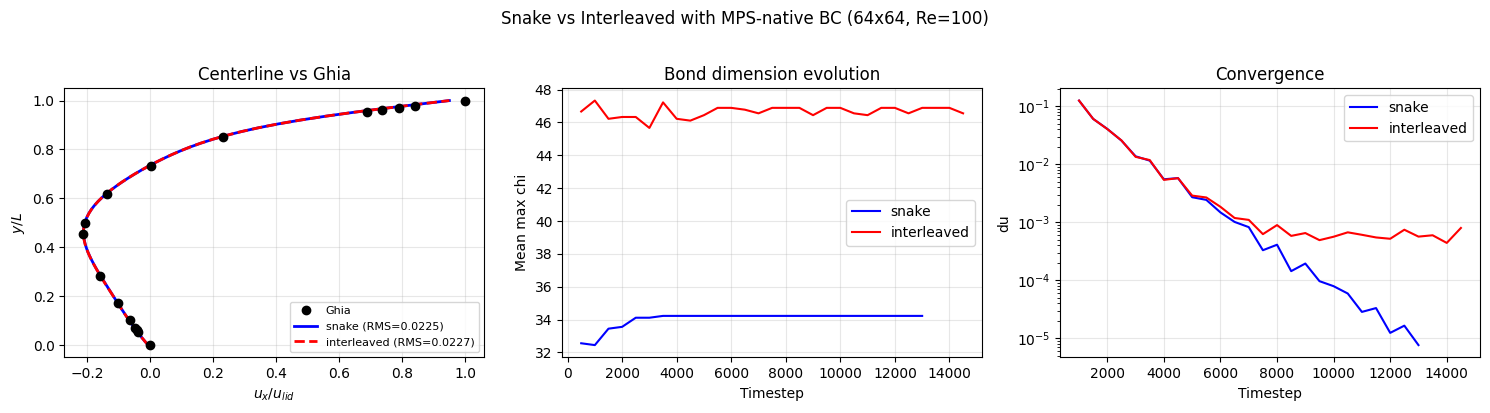

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ghia comparison
ax = axes[0]
y_coords = np.linspace(0, 1, n)
ax.plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=6, label='Ghia', zorder=5)
for m, color, ls in [('snake', 'blue', '-'), ('interleaved', 'red', '--')]:
    r = results_map[m]
    mid = n // 2
    ax.plot(r['u'][0, mid, :]/u_lid, y_coords, color=color, linestyle=ls, 
            linewidth=2, label=f"{m} (RMS={r['rms_ghia']:.4f})")
ax.set_xlabel('$u_x / u_{lid}$'); ax.set_ylabel('$y / L$')
ax.set_title('Centerline vs Ghia'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Bond dimension over time
ax = axes[1]
for m, color in [('snake', 'blue'), ('interleaved', 'red')]:
    h = results_map[m]['hist']
    ax.plot(h['t'], h['mean_chi'], color=color, label=m)
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean max chi')
ax.set_title('Bond dimension evolution'); ax.legend(); ax.grid(True, alpha=0.3)

# Convergence
ax = axes[2]
for m, color in [('snake', 'blue'), ('interleaved', 'red')]:
    h = results_map[m]['hist']
    ax.semilogy(h['t'][1:], h['du'][1:], color=color, label=m)
ax.set_xlabel('Timestep'); ax.set_ylabel('du')
ax.set_title('Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Snake vs Interleaved with MPS-native BC ({n}x{n}, Re={Re})', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Converged velocity fields: vanilla vs snake vs interleaved
_, u_van_final = compute_moments(D2Q9, f_van)
speed_van = np.sqrt(u_van_final[0]**2 + u_van_final[1]**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vmax = speed_van.max()

# Top row: velocity fields
for ax, (label, r) in zip(axes[0], [('Vanilla', {'u': u_van_final}),
                                      ('Snake (MPS BC)', results_map['snake']),
                                      ('Interleaved (MPS BC)', results_map['interleaved'])]):
    speed = np.sqrt(r['u'][0]**2 + r['u'][1]**2)
    im = ax.imshow(speed.T, origin='lower', cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(label); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Bottom row: absolute difference vs vanilla
for ax, (label, mapping) in zip(axes[1], [('', None),
                                            ('|Snake - Vanilla|', 'snake'),
                                            ('|Interleaved - Vanilla|', 'interleaved')]):
    if mapping is None:
        ax.axis('off')
        continue
    speed_mps = np.sqrt(results_map[mapping]['u'][0]**2 + results_map[mapping]['u'][1]**2)
    diff = np.abs(speed_van - speed_mps)
    im = ax.imshow(diff.T, origin='lower', cmap='hot')
    ax.set_title(f'{label}\n(max={diff.max():.2e})'); ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f'Converged velocity fields ({n}x{n}, Re={Re})', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Centerline profiles: all three + Ghia
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
y_coords = np.linspace(0, 1, n)
mid = n // 2

ax = axes[0]
ax.plot(GHIA_U_RE100, GHIA_Y, 'ko', markersize=7, label='Ghia et al.', zorder=5)
ax.plot(u_van_final[0, mid, :]/u_lid, y_coords, 'k-', linewidth=2, label=f'Vanilla (RMS={0.045951:.4f})')
ax.plot(results_map['snake']['u'][0, mid, :]/u_lid, y_coords, 'b--', linewidth=2,
        label=f'Snake MPS BC (RMS={results_map["snake"]["rms_ghia"]:.4f})')
ax.plot(results_map['interleaved']['u'][0, mid, :]/u_lid, y_coords, 'r:', linewidth=2,
        label=f'Intlv MPS BC (RMS={results_map["interleaved"]["rms_ghia"]:.4f})')
ax.set_xlabel('$u_x / u_{lid}$'); ax.set_ylabel('$y / L$')
ax.set_title('Centerline velocity'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ux_van_interp = np.interp(GHIA_Y, y_coords, u_van_final[0, mid, :] / u_lid)
ax.plot(GHIA_Y, np.abs(ux_van_interp - GHIA_U_RE100), 'k^-', markersize=5,
        label=f'Vanilla (RMS={0.045951:.4f})')
ax.plot(GHIA_Y, np.abs(results_map['snake']['ux_center'] - GHIA_U_RE100), 'bs-', markersize=5,
        label=f'Snake (RMS={results_map["snake"]["rms_ghia"]:.4f})')
ax.plot(GHIA_Y, np.abs(results_map['interleaved']['ux_center'] - GHIA_U_RE100), 'ro-', markersize=5,
        label=f'Interleaved (RMS={results_map["interleaved"]["rms_ghia"]:.4f})')
ax.set_xlabel('$y / L$'); ax.set_ylabel('|error vs Ghia|')
ax.set_title('Pointwise error vs benchmark'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle(f'Vanilla vs MPS-native BC ({n}x{n}, Re={Re})', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()